In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Librerías de Procesamiento de Lenguaje Natural (NLP)
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize
import re # Para expresiones regulares (limpiar símbolos)

# Recursos lingüísticos necesarios para el español
nltk.download('punkt')           # Tokenizador
nltk.download('stopwords') 
nltk.download('punkt_tab') # Palabras comunes sin valor semántico

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\jonba\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jonba\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\jonba\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [3]:
text = os.path.join('Datos', "BilbaolaVieja_booking_reviews_todas.csv")
df = pd.read_csv(text)

In [4]:
def clean_text_round(text):
    text = re.sub('\r', '', text)
    text = re.sub('\n', ' ', text)
    text = re.sub('Â', '', text)
    text = re.sub('\u200a', '', text)
    return text

In [5]:
df['full_review'] = df['positive'].fillna('') + ' ' + df['negative'].fillna('')

In [6]:
df['full_review'] = df['full_review'].apply(clean_text_round)

In [16]:
lines = " ".join(df['full_review'])

In [17]:
sentences = sent_tokenize(lines)
total_documents = len(sentences)


In [18]:
documents_tokens = []

for sentence in sentences:
    tokens = word_tokenize(sentence, language='spanish')
    documents_tokens.append(tokens)


In [19]:
all_words = []

for doc in documents_tokens:
    all_words.extend(doc)

all_words = [w.lower() for w in all_words if w.isalpha()]



In [20]:
from sklearn.feature_extraction.text import CountVectorizer

# Stopwords en español
stop_words = stopwords.words('spanish')

vectorizer = CountVectorizer(
    stop_words=stop_words,
    lowercase=True
)

X = vectorizer.fit_transform(sentences)


In [21]:
X.shape


(161, 800)

In [22]:
tdm = pd.DataFrame(
    X.toarray(),
    columns=vectorizer.get_feature_names_out()
)


In [23]:
word_freq = tdm.sum(axis=0).sort_values(ascending=False)
print(word_freq.head(10))


cama           46
sofá           34
ubicación      28
apartamento    27
limpio         27
limpieza       24
barrio         19
bien           18
zona           18
centro         18
dtype: int64


In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords

stop_words = stopwords.words('spanish')

tf_vectorizer = TfidfVectorizer(
    use_idf=False,      # solo TF
    norm='l1',          # normaliza por documento
    stop_words=stop_words,  # quita stopwords
    lowercase=True
)

X_tf = tf_vectorizer.fit_transform(sentences)

# Convertir a DataFrame
tf_matrix = pd.DataFrame(
    X_tf.toarray(),
    columns=tf_vectorizer.get_feature_names_out()
)

print(tf_matrix.head())


    02        10   11  11am  11h  11h02   12   15  15h   20  ...  wau  xungo  \
0  0.0  0.000000  0.0   0.0  0.0    0.0  0.0  0.0  0.0  0.0  ...  0.0    0.0   
1  0.0  0.000000  0.0   0.0  0.0    0.0  0.0  0.0  0.0  0.0  ...  0.0    0.0   
2  0.0  0.000000  0.0   0.0  0.0    0.0  0.0  0.0  0.0  0.0  ...  0.0    0.0   
3  0.0  0.071429  0.0   0.0  0.0    0.0  0.0  0.0  0.0  0.0  ...  0.0    0.0   
4  0.0  0.000000  0.0   0.0  0.0    0.0  0.0  0.0  0.0  0.0  ...  0.0    0.0   

       zona  zonas  zócalo  época   és  íbamos  única  únicamente  
0  0.000000    0.0     0.0    0.0  0.0     0.0    0.0         0.0  
1  0.200000    0.0     0.0    0.0  0.0     0.0    0.0         0.0  
2  0.142857    0.0     0.0    0.0  0.0     0.0    0.0         0.0  
3  0.000000    0.0     0.0    0.0  0.0     0.0    0.0         0.0  
4  0.000000    0.0     0.0    0.0  0.0     0.0    0.0         0.0  

[5 rows x 800 columns]


In [25]:
# Convertir a binario: 1 si aparece, 0 si no
binary_matrix = (tf_matrix > 0).astype(int)

# Sumar por columna → cuántas frases contienen cada palabra
word_in_sentences = binary_matrix.sum(axis=0)
word_in_sentences_sorted = word_in_sentences.sort_values(ascending=False)
print(word_in_sentences_sorted.head(10))


cama           38
sofá           28
apartamento    25
ubicación      25
limpio         24
limpieza       19
barrio         18
centro         17
zona           17
cerca          16
dtype: int64


In [26]:
N = tf_matrix.shape[0]

idf_vector = np.log(N / word_in_sentences)
print(idf_vector.sort_values(ascending=False).head(10))


violentos     5.081404
vio           5.081404
vino          5.081404
vimos         5.081404
vienes        5.081404
viene         5.081404
viajábamos    5.081404
viajeros      5.081404
ver           5.081404
venían        5.081404
dtype: float64


In [27]:
tfidf_matrix0 = tf_matrix * idf_vector


In [28]:
print(tfidf_matrix0.iloc[3].sort_values(ascending=False).head(10))


estabamoa    0.362957
nervion      0.362957
maravilla    0.362957
perfecta     0.362957
rio          0.362957
10           0.313447
igual        0.313447
andando      0.284485
minutos      0.263936
bilbao       0.247998
Name: 3, dtype: float64


In [29]:
sentence_scores = tfidf_matrix0.apply(
    lambda row: row[row > 0].mean(),
    axis=1
)
print(sentence_scores.sort_values(ascending=False).head(10))


40     5.081404
124    5.081404
151    5.081404
79     5.081404
80     3.982792
41     3.982792
26     3.982792
139    2.540702
150    2.540702
149    2.367415
dtype: float64


In [30]:
average_score = sentence_scores.mean()
average_score

np.float64(0.9389365788062237)

In [31]:
def _generate_summary(sentences, sentence_scores, average_score):
    summary = ''
    sentence_count = 0
    
    for i, sentence in enumerate(sentences):
        if sentence_scores.iloc[i] >= average_score:
            summary += " " + sentence
            sentence_count += 1
            
    return summary


In [32]:
summary = _generate_summary(sentences, sentence_scores, 1.3 * average_score)
print(summary)

 Como cama no lo probamos. Su limpieza y comodidad. Todo nos gustó. Aparcar es complicado. Tuve que comprobarlo. ¡Cuidado! El sistema de llaves. Ampliar apartamentos para los 5. La ubicación. Muy buenos detalles para nuestra perra. Muy cerca hay un parque para sacarla. Lo más problemático es el aparcamiento. Escasez de utensilios de cocina. Había una cucaracha en la habitación. Exelente me dejo sin palabras! el sofá. cama. k nos clavamos. los hierros. Tampoco había escoba. La puerta está sucísima. Hay aparcamiento en los alrededores. Varias personas también lo hicieron. No lo recomendamos. Los sofascamas son muy incómodos porque los colchones están hundidos. Pasamos mala noche. La ubicación. La cama. Totalmente doblado. Horroroso para alguien con problemas de espalda como yo. Todo muy limpio . La Localización y la limpieza. Demasiado impersonal. Todo es automático, y se paga por todo. No hay maleabilidad. Era como en las fotos, y estaba limpio. Muy bueno 👌 Todo bien 🙂


In [33]:
# opiniones negativas
neg_reviews = df['negative'].dropna()

sentences = []
for review in neg_reviews:
    sentences.extend(sent_tokenize(review, language='spanish'))

print(f"Número de frases negativas: {len(sentences)}")


Número de frases negativas: 163


In [34]:
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

# Definir stopwords en español
stop_words_es = stopwords.words('spanish')

tfidf_vectorizer = TfidfVectorizer(
    stop_words=stop_words_es,  # <- nombre correcto
    lowercase=True,
    max_df=0.9,
    min_df=5,
    ngram_range=(1,2)
)

tfidf_matrix = tfidf_vectorizer.fit_transform(sentences)


In [35]:
from sklearn.cluster import KMeans

k = 4
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(tfidf_matrix)

labels = kmeans.labels_


In [36]:
import numpy as np

# Número de palabras a mostrar por cluster
top_n = 15

# Nombres de las palabras del TF-IDF
feature_names = tfidf_vectorizer.get_feature_names_out()

# Orden de importancia de cada palabra en cada cluster
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]  # de mayor a menor

# Mostrar las top 15 palabras por cluster
for i in range(k):  # k = número de clusters
    print(f"\nCluster {i} - Top {top_n} palabras clave:")
    top_words = [feature_names[ind] for ind in order_centroids[i, :top_n]]
    print(", ".join(top_words))




Cluster 0 - Top 15 palabras clave:
cama, cocina, zona, sofá cama, sofá, ubicación, toallas, piso, personas, peor, noche, limpieza, incómodo, si, problema

Cluster 1 - Top 15 palabras clave:
ubicación, barrio, limpieza, personas, apartamento, zona, aparcar, cocina, calle, centro, piso, toallas, además, días, si

Cluster 2 - Top 15 palabras clave:
sofá, sofá cama, cama, incómodo, cama incómodo, incomodo, cama incomodo, barrio, peor, ubicación, además, piso, apartamento, aunque, cocina

Cluster 3 - Top 15 palabras clave:
noche, zona, barrio, sofá cama, sofá, si, ubicación, problema, piso, personas, peor, limpieza, incómodo, incomodo, toallas


In [41]:
from nltk.corpus import stopwords
nltk.download('stopwords')  # si no lo has hecho ya

stop_words_es = stopwords.words('spanish')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jonba\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [42]:
from sklearn.feature_extraction.text import TfidfVectorizer

tf_vectorizer = TfidfVectorizer(
    stop_words=stop_words_es,  # <- lista de NLTK
    lowercase=True
)

# Usar las mismas frases que para K-Means
neg_sentences = sentences  # o la lista exacta usada para labels

X_tf = tf_vectorizer.fit_transform(neg_sentences)
tfidf_matrix0 = pd.DataFrame(X_tf.toarray(), columns=tf_vectorizer.get_feature_names_out())



In [46]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', None)

top_n_words = 15
top_n_sentences = 5
k = len(np.unique(labels))

# Diccionario para nombrar clusters según interpretación de palabras
# Puedes ajustar los nombres según lo que observes
cluster_names = {
    0: "Comodidad y equipamiento",
    1: "Ubicación y accesibilidad",
    2: "Limpieza y confort",
    3: "Comodidad + ubicación"
}

for i in range(k):
    # Frases del cluster
    cluster_sentences = [sent for sent, label in zip(sentences, labels) if label == i]
    
    # TF-IDF promedio por palabra dentro del cluster
    cluster_rows = tfidf_matrix0.iloc[[j for j, l in enumerate(labels) if l == i]]
    tfidf_mean = cluster_rows.mean(axis=0)
    
    # Top palabras
    top_words = tfidf_mean.sort_values(ascending=False).head(top_n_words).index.tolist()
    
    print(f"\nCluster {i} - {cluster_names.get(i, 'Tema desconocido')}")
    print(f"Top {top_n_words} palabras: {', '.join(top_words)}")
    
    # Ejemplos de frases
    print(f"Ejemplos de frases ({top_n_sentences}):")
    for sent in cluster_sentences[:top_n_sentences]:
        print("-", sent)



Cluster 0 - Comodidad y equipamiento
Top 15 palabras: cama, incomoda, probamos, tremendamente, despliegas, minúsculo, mínimo, echamos, incómoda, menos, pareció, trapos, estudio, queda, niño
Ejemplos de frases (5):
- Como cama no lo probamos.
- La cama nos pareció un poco incómoda y echamos de menos trapos de cocina.
- Cuando despliegas la cama el estudio se queda minúsculo y con un espacio mínimo
- La cama supletoria muy incomoda, no de puede dormir, a lo sumo un niño, i no muchas noches
- la cama.

Cluster 1 - Ubicación y accesibilidad
Top 15 palabras: ubicación, barrio, apartamento, zona, aparcar, personas, centro, calle, limpieza, acondicionado, aire, toallas, sofa, cocina, días
Ejemplos de frases (5):
- No hay zona gratuita para aparcar cerca pero no sale muy caro el estacionamiento.
- Además no nos dejaron papel higiénico en ningún baño, por lo demás bien estaba muy limpio y cuidado todo.
- Pero el apartamento tiene ascensor y es cómodo.
- Al ser un estudio se quedaba un poco peq

## separacion


Descarga de los CSV

In [ ]:
df_vitoria=pd.read_csv("Vitoria_booking_reviews_todas.csv")
df_donosti=pd.read_csv("Donosti_booking_reviews_todas.csv")
df_BilbaoMuseo=pd.read_csv("BilbaoMuseo_booking_reviews_todas.csv")
df_BilbaolaVieja=pd.read_csv("BilbaolaVieja_booking_reviews_todas.csv")
df_CodobaPatio=pd.read_csv("CordobaPatio_booking_reviews_todas.csv")
df_GranadaCatedral=pd.read_csv("GranadaCatedral_booking_reviews_todas.csv")
df_MadridPalacioReal=pd.read_csv("MadridPalacioReal_booking_reviews_todas.csv")
df_MalagaLaMerced=pd.read_csv("MalagaLaMerced_booking_reviews_todas.csv")
df_MalagaTeatroRomano=pd.read_csv("MalagaTeatroRomano_booking_reviews_todas.csv")
df_PamplonaYamaguchi=pd.read_csv("PamplonaYamaguchi_booking_reviews_todas.csv")
df_ValenciaAbastos=pd.read_csv("ValenciaAbastos_booking_reviews_todas.csv")
df_ValenciaJardinBotanico=pd.read_csv("ValenciaJardinBotanico_booking_reviews_todas.csv")

In [ ]:
# --- Crear un diccionario con los DataFrames y el nombre del hotel ---
files_hotels = {
    "Vitoria_booking_reviews_todas.csv": "Vitoria",
    "Donosti_booking_reviews_todas.csv": "Donosti",
    "BilbaoMuseo_booking_reviews_todas.csv": "BilbaoMuseo",
    "BilbaolaVieja_booking_reviews_todas.csv": "BilbaolaVieja",
    "CordobaPatio_booking_reviews_todas.csv": "CordobaPatio",
    "GranadaCatedral_booking_reviews_todas.csv": "GranadaCatedral",
    "MadridPalacioReal_booking_reviews_todas.csv": "MadridPalacioReal",
    "MalagaLaMerced_booking_reviews_todas.csv": "MalagaLaMerced",
    "MalagaTeatroRomano_booking_reviews_todas.csv": "MalagaTeatroRomano",
    "PamplonaYamaguchi_booking_reviews_todas.csv": "PamplonaYamaguchi",
    "ValenciaAbastos_booking_reviews_todas.csv": "ValenciaAbastos",
    "ValenciaJardinBotanico_booking_reviews_todas.csv": "ValenciaJardinBotanico"
}

all_dfs = []

# --- Leer cada CSV, añadir columna "hotel", y almacenar en lista ---
for file, hotel_name in files_hotels.items():
    df = pd.read_csv(file, encoding="utf-8-sig")
    df["hotel"] = hotel_name
    all_dfs.append(df)

# --- Concatenar todos los DataFrames ---
df_all_hotels = pd.concat(all_dfs, ignore_index=True)

# --- Guardar CSV final ---
df_all_hotels.to_csv("Todos_hoteles_booking_reviews.csv", index=False, encoding="utf-8-sig")

print(f"TOTAL RESEÑAS COMBINADAS: {len(df_all_hotels)}")

In [ ]:
df=pd.read_csv("Todos_hoteles_booking_reviews.csv")
df.shape

Calculo de la media, mediana, maximo, minimo

In [ ]:
def tabla_puntuaciones(diccionario_hoteles):
    """
    Recibe un diccionario con nombre del hotel y su DataFrame
    y devuelve una tabla con MEDIA, MEDIANA, MODA, MÁXIMO y MÍNIMO.
    """
    
    resultados = []

    for hotel, df in diccionario_hoteles.items():
        # Asegurar que score es numérico
        scores = pd.to_numeric(df['score'], errors='coerce').dropna()
        
        resultados.append({
            "HOTEL": hotel,
            "MEDIA": round(scores.mean(), 2),
            "MEDIANA": scores.median(),
            "MODA": scores.mode().iloc[0] if not scores.mode().empty else None,
            "MÁXIMO": scores.max(),
            "MÍNIMO": scores.min()
        })
    
    return pd.DataFrame(resultados)

In [ ]:
hoteles = {
    "Líbere Vitoria": df_vitoria,
    "Koisi Hostel Donostia": df_donosti,
    "Líbere Bilbao Museo": df_BilbaoMuseo,
    "Líbere Bilbao La Vieja": df_BilbaolaVieja,
    "Líbere Córdoba Patio": df_CodobaPatio,
    "Líbere Granada Catedral": df_GranadaCatedral,
    "Líbere Madrid Palacio Real": df_MadridPalacioReal,
    "Líbere Málaga La Merced": df_MalagaLaMerced,
    "Líbere Málaga Teatro Romano": df_MalagaTeatroRomano,
    "Líbere Pamplona Yamaguchi": df_PamplonaYamaguchi,
    "Líbere Valencia Abastos": df_ValenciaAbastos,
    "Líbere Valencia Jardín Botánico": df_ValenciaJardinBotanico
}

In [ ]:
tabla_scores = tabla_puntuaciones(hoteles)
tabla_scores

## Tabla de frecuencias y wordcloud y graficos

In [47]:
negative_reviews = df['negative'].dropna()
negative_reviews = negative_reviews.apply(clean_text_round)

# Unir todo el texto negativo
negative_text = " ".join(negative_reviews)

In [48]:
# Tokenizar palabras
tokens_neg = word_tokenize(negative_text, language='spanish')

# Limpiar: minúsculas, alfabéticas, sin stopwords
stop_words_es = stopwords.words('spanish')

tokens_neg_clean = [
    w.lower() for w in tokens_neg
    if w.isalpha() and w.lower() not in stop_words_es
]

In [49]:
# Tabla de frecuencias
freq_neg = pd.Series(tokens_neg_clean).value_counts()

# Convertir a DataFrame
freq_neg_df = freq_neg.reset_index()
freq_neg_df.columns = ['Palabra', 'Frecuencia']

print("\nTop 20 palabras negativas más frecuentes:")
print(freq_neg_df.head(20))


Top 20 palabras negativas más frecuentes:
          Palabra  Frecuencia
0            cama          38
1            sofá          29
2          barrio          17
3            zona          15
4       ubicación          15
5     apartamento          12
6        personas           8
7          centro           8
8         toallas           8
9           calle           8
10       limpieza           8
11          noche           8
12       incómodo           8
13         cocina           7
14           piso           6
15  acondicionado           6
16           aire           6
17           días           6
18         aunque           6
19             si           6


In [50]:
freq_neg_df.to_csv("frecuencias_palabras_negativas.csv", index=False)

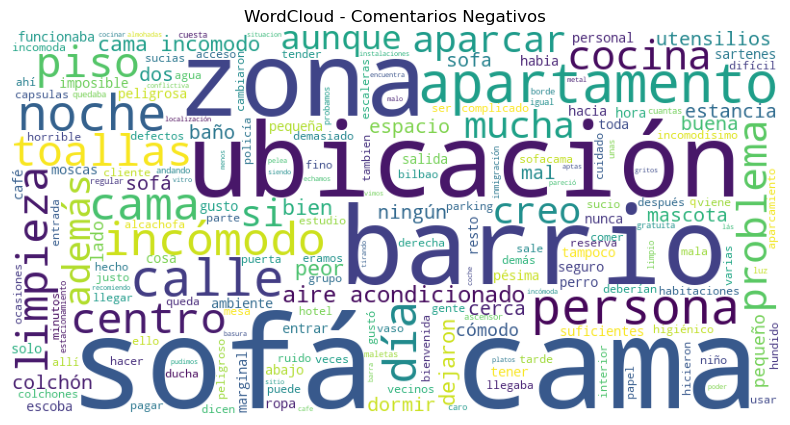

In [53]:
from wordcloud import WordCloud

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(" ".join(tokens_neg_clean))

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud)
plt.axis('off')
plt.title("WordCloud - Comentarios Negativos")
plt.show()

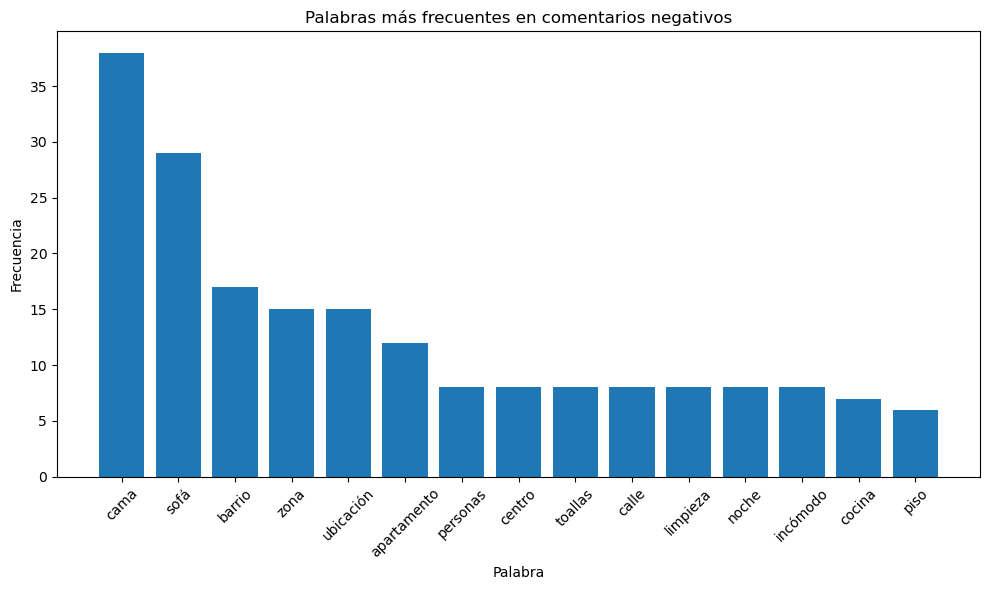

In [54]:
top_n = 15
top_words = freq_neg_df.head(top_n)

plt.figure(figsize=(10, 6))
plt.bar(top_words['Palabra'], top_words['Frecuencia'])
plt.xticks(rotation=45)
plt.title("Palabras más frecuentes en comentarios negativos")
plt.xlabel("Palabra")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()